# Week 5 — The Airy Wave and the Dispersion Relation

**OE 754 / 854 — Ocean Waves & Tides**

This week we have the Airy (small-amplitude) solution in hand:

$$\eta(x,t) = \tfrac{H}{2}\cos(kx - \omega t), \qquad
  \phi(x,z,t) = \frac{gH}{2\omega}\,\frac{\cosh k(h+z)}{\cosh kh}\sin(\omega t - kx),$$

closed by the **dispersion relation**

$$\boxed{\;\omega^2 = g k \tanh(kh).\;}$$

The dispersion relation is transcendental in $k$. Given $\omega$ (or $T$) and $h$, you can't rearrange it to isolate $k$. This notebook covers three numerical ways to invert it. We also take a first computational look at the solution across the deep / intermediate / shallow regimes.

**Goals for the notebook**

1. Compare three methods for solving $\omega^2 = gk\tanh kh$: fixed-point iteration on $L$, Newton's method on $k$, and the Hunt (1979) closed-form approximation.
2. Reproduce the worked example from the lecture notes ($T = 8\,\text{s}$, $h = 10\,\text{m}$) and check the convergence pattern.
3. Plot $C$, $C_g$, and $n = C_g/C$ against $kh$ across the shallow/intermediate/deep regimes. Read the asymptotic limits off the curves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import figure_style as fs  # seaborn 'ticks', course palette, figure sizes

g = 9.81  # m/s^2

## 1. Four solvers for the dispersion relation

### (i) Fixed-point iteration on $L$

Rewrite the dispersion relation as

$$L = L_0 \tanh\!\left(\frac{2\pi h}{L}\right), \qquad L_0 = \frac{gT^2}{2\pi}.$$

Start from $L^{(0)} = L_0$ (the deep-water wavelength) and iterate. Convergence is slow in intermediate depth (we get to the reason below). But it's one keystroke per iteration on a calculator, so the notes recommend it for quick work.

In [2]:
def L_from_T_fixedpoint(T, h, tol=1e-10, max_iter=200, record=False):
    r'''Solve the dispersion relation by iterating L = L0 * tanh(2 pi h / L).

    With record=True, also return the iterate history.
    '''
    L0 = g * T**2 / (2 * np.pi)
    L = L0
    history = [L]
    for _ in range(max_iter):
        L_new = L0 * np.tanh(2 * np.pi * h / L)
        history.append(L_new)
        if abs(L_new - L) < tol:
            L = L_new
            break
        L = L_new
    return (L, np.array(history)) if record else L


### (ii) Newton's method on $k$

Define $f(k) = \omega^2 - gk\tanh(kh)$. Then

$$f'(k) = -g\tanh(kh) - ghk\,\operatorname{sech}^2(kh).$$

Start from the deep-water estimate $k^{(0)} = \omega^2/g$ and iterate $k \leftarrow k - f(k)/f'(k)$. Newton converges quadratically once close. In intermediate depth, that is much faster than fixed-point iteration.

In [3]:
def k_from_omega_newton(omega, h, tol=1e-12, max_iter=50, record=False):
    r'''Solve omega^2 = g k tanh(kh) for k by Newton's method.'''
    k = omega**2 / g  # deep-water start
    history = [k]
    for _ in range(max_iter):
        tkh = np.tanh(k * h)
        f = omega**2 - g * k * tkh
        fp = -g * tkh - g * h * k * (1 - tkh**2)  # sech^2 = 1 - tanh^2
        dk = f / fp
        k_new = k - dk
        history.append(k_new)
        if abs(dk) < tol:
            k = k_new
            break
        k = k_new
    return (k, np.array(history)) if record else k


### (iii) Hunt (1979) closed-form approximation

This approach gives $(kh)^2$ as a function of $y \equiv \omega^2 h / g$ through

$$(kh)^2 \;\approx\; y^2 + \frac{y}{1 + \sum_{n=1}^{6} d_n\,y^n},$$

with the coefficients $d_n$ below. It is accurate to better than $0.1\%$ over the whole range. It is also non-iterative. That helps if you evaluate the dispersion relation millions of times inside a spectral wave solver.

In [4]:
def k_from_omega_hunt(omega, h):
    r'''Hunt (1979) closed-form approximation to k from omega and h.'''
    y = omega**2 * h / g
    d = [0.6666666667, 0.3555555556, 0.1608465608,
         0.0632098765, 0.0217540484, 0.0065407983]
    denom = 1.0
    for n, dn in enumerate(d, start=1):
        denom += dn * y**n
    kh_sq = y**2 + y / denom
    return np.sqrt(kh_sq) / h


### (iv) Eckart (1953) closed-form approximation

This approach is the least sophisticated and least accurate of the four, but easiest to memorize and implement given access to a simple scientific calculator:

$$\omega^2=gk\sqrt{tanh(\omega^2h/g)}$$


In [9]:
def k_from_omega_eckart(omega, h):
    r'''Eckart (1953) closed-form approximation to k from omega and h.'''
    y = omega**2 * h / g
    return omega**2 / np.sqrt(np.tanh(y)) / g


## 2. Worked example: $T = 8\,\text{s}$, $h = 10\,\text{m}$

Let's compare the four methods.

In [10]:
T = 8.0
h = 10.0
omega = 2 * np.pi / T
L0 = g * T**2 / (2 * np.pi)

# Fixed point on L
L_fp, hist_L = L_from_T_fixedpoint(T, h, record=True)
hist_k_fp = 2 * np.pi / hist_L

# Newton on k
k_nw, hist_k_nw = k_from_omega_newton(omega, h, record=True)

# Hunt closed form
k_hunt = k_from_omega_hunt(omega, h)

# Eckart closed form
k_eckart = k_from_omega_eckart(omega, h)

print(f"L_0 (deep-water wavelength) = {L0:7.3f} m")
print(f"Fixed-point iteration:   L   = {L_fp:7.3f} m,  k = {2*np.pi/L_fp:7.5f} rad/m, "
      f"converged in {len(hist_L)} iterations")
print(f"Newton's method on k:    k   = {k_nw:7.5f} rad/m,  L = {2*np.pi/k_nw:7.3f} m, "
      f"converged in {len(hist_k_nw)} iterations")
print(f"Hunt closed form:        k   = {k_hunt:7.5f} rad/m,  L = {2*np.pi/k_hunt:7.3f} m")
print(f"Eckart closed form:        k   = {k_eckart:7.5f} rad/m,  L = {2*np.pi/k_eckart:7.3f} m")

L_0 (deep-water wavelength) =  99.924 m
Fixed-point iteration:   L   =  70.898 m,  k = 0.08862 rad/m, converged in 58 iterations
Newton's method on k:    k   = 0.08862 rad/m,  L =  70.898 m, converged in 6 iterations
Hunt closed form:        k   = 0.08862 rad/m,  L =  70.898 m
Eckart closed form:        k   = 0.08424 rad/m,  L =  74.591 m


Plot the convergence side by side.

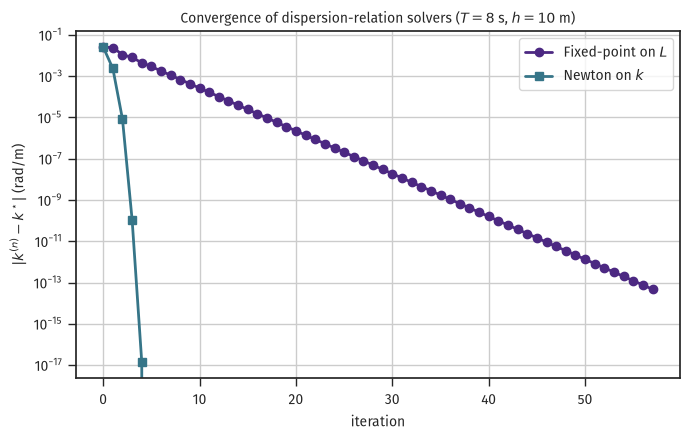

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

k_true = k_nw  # reference, Newton at tol 1e-12

err_fp = np.abs(hist_k_fp - k_true)
err_nw = np.abs(hist_k_nw - k_true)

ax.semilogy(err_fp, 'o-', label='Fixed-point on $L$', lw=2, ms=6)
ax.semilogy(err_nw, 's-', label="Newton on $k$", lw=2, ms=6)
ax.set_xlabel('iteration')
ax.set_ylabel(r'$|k^{(n)} - k^\star|$ (rad/m)')
ax.set_title(r'Convergence of dispersion-relation solvers ($T=8$ s, $h=10$ m)')
ax.legend()
plt.tight_layout()
plt.show()

Fixed-point is linearly convergent. The rate is set by $|\tanh'|$ at the fixed point, so it's slow in intermediate depth. Newton is quadratically convergent once close, so it drops off the bottom of the plot in a few steps.

### Exercise

The first Newton iterate from $k^{(0)} = \omega^2/g$ already lands within about 3 % of the true answer here. Why? What does that starting value correspond to physically? How accurate would it be in deeper water ($h = 100\,\text{m}$)? In shallower water ($h = 1\,\text{m}$)?

## 3. Regime sweep: $C$, $C_g$, and $n = C_g/C$ vs. $kh$

The dispersion relation passes smoothly between two limits:

- **Deep water** ($kh \gg 1$): $\tanh kh \to 1$, so $\omega^2 \to gk$, giving $C = g/\omega = gT/(2\pi)$ and $C_g = C/2$. Dispersive.
- **Shallow water** ($kh \ll 1$): $\tanh kh \to kh$, so $\omega^2 \to g k^2 h$, giving $C = \sqrt{gh}$ and $C_g = C$. Non-dispersive.

Plot $C$ and $C_g$ against $kh$ to see the transition. Nondimensionalize by the shallow-water speed $\sqrt{gh}$ so both limits show on the same axis.

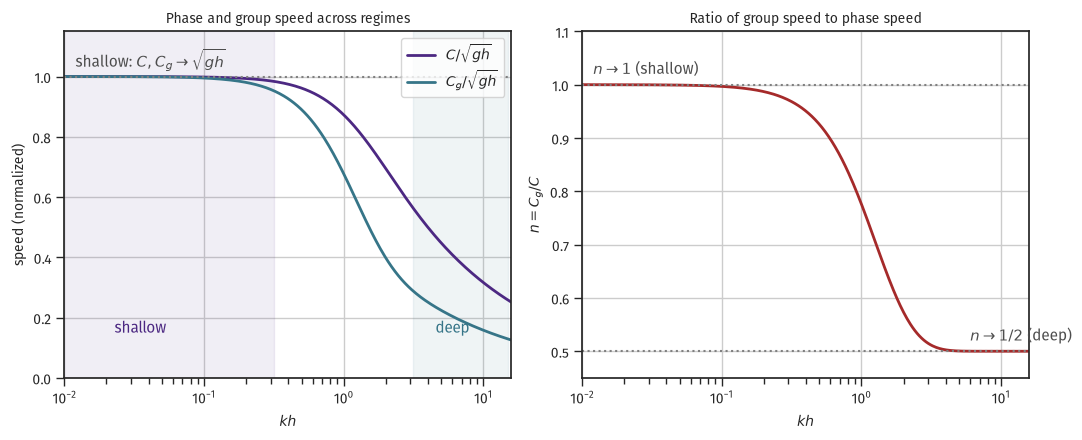

In [7]:
kh = np.logspace(-2, 1.2, 400)  # 0.01 to ~15
tkh = np.tanh(kh)

# Phase and group speed, normalized by sqrt(gh):
# C = sqrt(g tanh(kh)/k) = sqrt(gh) sqrt(tanh(kh)/kh), C_g = nC,
# n = (1/2)(1 + 2kh/sinh(2kh))
C_over_sqrtgh = np.sqrt(tkh / kh)
n = 0.5 * (1 + 2 * kh / np.sinh(2 * kh))
Cg_over_sqrtgh = n * C_over_sqrtgh

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.semilogx(kh, C_over_sqrtgh, label=r'$C/\sqrt{gh}$', lw=2)
ax1.semilogx(kh, Cg_over_sqrtgh, label=r'$C_g/\sqrt{gh}$', lw=2)
ax1.axhline(1.0, color='0.5', ls=':', lw=1.5)
ax1.text(0.012, 1.03, r'shallow: $C, C_g \to \sqrt{gh}$', fontsize=11, color='0.3')
ax1.set_xlabel(r'$kh$')
ax1.set_ylabel('speed (normalized)')
ax1.set_title('Phase and group speed across regimes')
ax1.legend(loc='upper right')
ax1.axvspan(0.01, np.pi / 10, alpha=0.08, color=fs.color_list[0])
ax1.axvspan(np.pi, 15, alpha=0.08, color=fs.color_list[1])
ax1.text(0.035, 0.15, 'shallow', fontsize=11, color=fs.color_list[0], ha='center')
ax1.text(6.0,   0.15, 'deep',    fontsize=11, color=fs.color_list[1], ha='center')
ax1.set_xlim(kh.min(), kh.max())
ax1.set_ylim(0, 1.15)

ax2.semilogx(kh, n, lw=2, color=fs.color_list[2])
ax2.axhline(1.0, color='0.5', ls=':', lw=1.5)
ax2.axhline(0.5, color='0.5', ls=':', lw=1.5)
ax2.text(0.012, 1.02, r'$n \to 1$ (shallow)', fontsize=11, color='0.3')
ax2.text(6.0,   0.52, r'$n \to 1/2$ (deep)', fontsize=11, color='0.3')
ax2.set_xlabel(r'$kh$')
ax2.set_ylabel(r'$n = C_g / C$')
ax2.set_title(r'Ratio of group speed to phase speed')
ax2.set_ylim(0.45, 1.1)
ax2.set_xlim(kh.min(), kh.max())

plt.tight_layout()
plt.show()

Three things from the plot on the left:

1. In shallow water both $C$ and $C_g$ collapse onto $\sqrt{gh}$. They move together, so there is no dispersion.
2. In deep water $C_g$ is half of $C$: energy propagates at half the phase speed. (We derive this wave-packet result in Week 7.)
3. The crossover between regimes takes about a decade in $kh$, from $\pi/10$ to $\pi$. Most engineering problems fall in this intermediate band. So we usually can't take the shallow- or deep-water shortcut. We need to solve the full dispersion relation.

## 4. The three regimes on the worked example

Return to $T = 8\,\text{s}$, $h = 10\,\text{m}$. Which regime are we in? How much error would the shallow- or deep-water shortcut introduce?

In [8]:
T = 8.0
h = 10.0
omega = 2 * np.pi / T

k_full  = k_from_omega_newton(omega, h)
L_full  = 2 * np.pi / k_full
C_full  = L_full / T
kh_full = k_full * h
n_full  = 0.5 * (1 + 2 * kh_full / np.sinh(2 * kh_full))
Cg_full = n_full * C_full

# Deep-water shortcut
L0 = g * T**2 / (2 * np.pi)
C0 = L0 / T
Cg0 = C0 / 2

# Shallow-water shortcut
C_sh  = np.sqrt(g * h)
Cg_sh = C_sh

print(f'kh = {kh_full:.3f}, intermediate (pi/10 < kh < pi)')
print()
print(f'{"":>18s}{"full":>12s}{"deep approx":>14s}{"shallow approx":>18s}')
print(f'{"L (m)":>18s}{L_full:>12.3f}{L0:>14.3f}{"n/a":>18s}')
print(f'{"C (m/s)":>18s}{C_full:>12.3f}{C0:>14.3f}{C_sh:>18.3f}')
print(f'{"C_g (m/s)":>18s}{Cg_full:>12.3f}{Cg0:>14.3f}{Cg_sh:>18.3f}')
print()
# tanh(kh) < min(kh, 1), so both limiting forms exceed the true C
print(f'deep-water C error    = {100*(C0-C_full)/C_full:+5.1f} %')
print(f'shallow-water C error = {100*(C_sh-C_full)/C_full:+5.1f} %')


kh = 0.886, intermediate (pi/10 < kh < pi)

                          full   deep approx    shallow approx
             L (m)      70.898        99.924               n/a
           C (m/s)       8.862        12.490             9.905
         C_g (m/s)       7.180         6.245             9.905

deep-water C error    = +40.9 %
shallow-water C error = +11.8 %


We're in intermediate depth: $kh = 0.886$. The deep-water approximation overshoots $C$ by around 41 %. The shallow-water one overshoots by about 12 %. Both limits always sit above the true celerity. $\tanh kh < kh$ for every $kh > 0$, so $C = \sqrt{(g/k)\tanh kh}$ is always below $\sqrt{gh}$. Also $\tanh kh < 1$, which puts it below the deep-water $\sqrt{g/k}$ as well. Neither shortcut is acceptable for design work at this depth. Use the full dispersion relation.

## 5. Exercise suggestions

These are the kinds of short computations we do all semester:

1. Plot $L$ against $T$ for three fixed depths $h = 5, 20, 100\,\text{m}$ on the same axes, across $T \in [2, 20]\,\text{s}$. Mark where each curve enters the deep-water regime ($h/L > 1/2$).

2. Pick any pair $(T, h)$ and time each of the three solvers with `%timeit`. Hunt's closed form should be tens of times faster than fixed-point iteration (more in shallow water, where fixed point needs many passes). Newton sits in between.

3. The fixed-point iteration converges even from a bad starting guess, but slowly. Try $L^{(0)} = 0.1\,L_0$ and $L^{(0)} = 10\,L_0$. Does it still converge? How many iterates?

4. (Analytical.) Show that, at the fixed point, the local contraction rate of the fixed-point iteration is

   $$\left|\frac{\partial}{\partial L}\!\left[L_0 \tanh(2\pi h / L)\right]\right|_{L = L^*}
     \;=\; \frac{2\pi h}{L^*}\,\frac{L_0}{L^*}\,\operatorname{sech}^2(2\pi h / L^*).$$

   Deep water: this is zero (one-step convergence). Shallow water: close to 1 (very slow). Intermediate: in between. Does that match the iterate counts above?

## Summary

> One formula: $\omega^2 = gk\tanh kh$ (the linear dispersion relation). You'll use it in every subsequent problem set in this course.

Exam 1 will ask you to derive it from scratch. Practice now.